# Transfer Learning MNIST

* Train a simple convnet on the MNIST dataset the first 5 digits [0-4].
* Freeze convolutional layers and fine-tune dense layers for the classification of digits [5-9].

## MNIST Dataset
The MNIST database contains 60,000 training images and 10,000 testing images taken from American Census Bureau employees and American high school students. The MNIST dataset is one of the most common datasets used for image classification and accessible from many different sources. In fact, even Tensorflow and Keras allow us to import and download the MNIST dataset directly from their API.

Let's import keras and load MNIST dataset

In [0]:
# Initialize the random number generator
import random
random.seed(0)

import warnings
warnings.filterwarnings("ignore")

In [0]:
from keras.backend import backend
from keras.datasets import mnist

# the data, shuffled and split between train and test sets
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [120]:
y_train[0:4]

array([5, 0, 4, 1], dtype=uint8)

X_train and X_test contain greyscale RGB codes (from 0 to 255) while y_train and y_test contains labels from 0 to 9 which represents which number they actually are.

Let's visualize some numbers using matplotlib

Label: 0


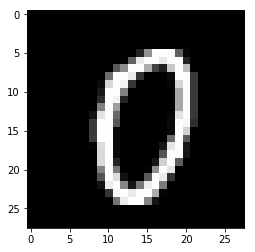

In [121]:
import matplotlib.pyplot as plt
%matplotlib inline
print("Label: {}".format(y_train[1000]))
plt.imshow(X_train[1000], cmap='gray')

## Question 1

### Create two datasets
- First having digits from 0 to 4
- Second having digits from 5 to 9

Hint: use labels to separate data

In [0]:
#Dataset 1
X_train_d1 = X_train[y_train < 5]
X_test_d1 = X_test[y_test < 5]
y_train_d1 = y_train[y_train < 5]
y_test_d1 = y_test[y_test < 5]

In [0]:
#Dataset 2
X_train_d2 = X_train[y_train >= 5]
X_test_d2 = X_test[y_test >= 5]
y_train_d2 = y_train[y_train >= 5]
y_test_d2 = y_test[y_test >= 5]

## Question 2

### Print shape of the data
- print shape of all variables of both the datasets you created

In [124]:
#Dataset 1 shapes
print('shape of X_train_d1',X_train_d1.shape)
print('shape of X_test_d1',X_test_d1.shape)
print('shape of y_train_d1',y_train_d1.shape)
print('shape of y_test_d1',y_test_d1.shape)

shape of X_train_d1 (30596, 28, 28)
shape of X_test_d1 (5139, 28, 28)
shape of y_train_d1 (30596,)
shape of y_test_d1 (5139,)


In [125]:
#Dataset 2 shapes
print('shape of X_train_d2',X_train_d2.shape)
print('shape of X_test_d2',X_test_d2.shape)
print('shape of y_train_d2',y_train_d2.shape)
print('shape of y_test_d2',y_test_d2.shape)

shape of X_train_d2 (29404, 28, 28)
shape of X_test_d2 (4861, 28, 28)
shape of y_train_d2 (29404,)
shape of y_test_d2 (4861,)


## Question 3

### Reshape data
- reshape first dataset
- To be able to use the dataset in Keras, we need 4-dims numpy arrays. 
- reshape features to pass it to a Conv2D layer
- channel = 1
- reshape features of first dataset only
- do not reshape labels

In [126]:
# Reshaping train data
X_train_d1 = X_train_d1.reshape(X_train_d1.shape[0], 28, 28, 1)
X_train_d1.shape

(30596, 28, 28, 1)

In [127]:
# Reshaping test data
X_test_d1 = X_test_d1.reshape(X_test_d1.shape[0], 28, 28, 1)
X_test_d1.shape

(5139, 28, 28, 1)

## Question 4

### Normalize data
- normalize first dataset
- we must normalize our data as it is always required in neural network models
- we can achieve this by dividing the RGB codes to 255 (which is the maximum RGB code minus the minimum RGB code)
- normalize X_train and X_test
- make sure that the values are float so that we can get decimal points after division

In [128]:
X_train_d1 = X_train_d1.astype('float32') / 255
X_train_d1.dtype

dtype('float32')

In [129]:
X_test_d1 = X_test_d1.astype('float32') / 255
X_test_d1.dtype

dtype('float32')

### Print shape of data and number of images
- for first dataset
- print shape of X_train
- print number of images in X_train
- print number of images in X_test

In [130]:
print('shape of X_train_d1',X_train_d1.shape)
print('shape of X_test_d1',X_test_d1.shape)

shape of X_train_d1 (30596, 28, 28, 1)
shape of X_test_d1 (5139, 28, 28, 1)


## Question 5

### One-hot encode the class vector
- encode labels of first dataset
- convert class vectors (integers) to binary class matrix
- convert y_train and y_test
- number of classes: 5
- we are doing this to use categorical_crossentropy as loss

Hint: you can use keras.utils.to_categorical

In [0]:
import tensorflow as tf

In [0]:
y_train_d1 = tf.keras.utils.to_categorical(y_train_d1,num_classes=5)

In [0]:
y_test_d1 = tf.keras.utils.to_categorical(y_test_d1,num_classes=5)

## Question 6
We will build our model by using high level Keras.

### Initialize a sequential model
- define a sequential model
- add 2 convolutional layers
    - no of filters: 32
    - kernel size: 3x3
    - activation: "relu"
    - input shape: (28, 28, 1) for first layer
- add a max pooling layer of size 2x2
- add a dropout layer
    - dropout layers fight with the overfitting by disregarding some of the neurons while training
    - use dropout rate 0.2

In [0]:
from keras.layers.core import Dense,Dropout,Activation,Flatten
from keras.layers.convolutional import Conv2D,MaxPooling2D

In [0]:
#Initialize Sequential model, reshape & normalize data
model = tf.keras.models.Sequential()

In [0]:
#Adding first convolutional layer
model.add(tf.keras.layers.Conv2D(32, #Number of filters 
                                 kernel_size=(3,3), #Size of the filter
                                 activation='relu'))

In [0]:
#Adding 2nd convolutional layer
model.add(tf.keras.layers.Conv2D(32, #Number of filters 
                                 kernel_size=(3,3), #Size of the filter
                                 activation='relu'))

In [0]:
#Adding MaxPooling layer
model.add(tf.keras.layers.MaxPool2D(pool_size=(2,2)))

In [0]:
#Adding dropout layer
model.add(tf.keras.layers.Dropout(0.2))

## Question 7

### Add classification layers
- do this after doing question 6
- flatten the data
    - add Flatten later
    - flatten layers flatten 2D arrays to 1D array before building the fully connected layers
- add 2 dense layers
    - number of neurons in first layer: 128
    - number of neurons in last layer: number of classes
    - activation function in first layer: relu
    - activation function in last layer: softmax
    - we may experiment with any number of neurons for the first Dense layer; however, the final Dense layer must have neurons equal to the number of output classes
- you can add a dropout layer in between, if necessary

In [0]:
#flatten the data
model.add(tf.keras.layers.Flatten())

In [0]:
#Dense layer
model.add(tf.keras.layers.Dense(128, activation='relu'))

#Add dropout layer
model.add(tf.keras.layers.Dropout(0.5))

#Output layer
model.add(tf.keras.layers.Dense(5, activation='softmax'))

## Question 8

### Compile and fit the model
- compile your model
    - loss: "categorical_crossentropy"
    - metrics: "accuracy"
    - optimizer: "sgd"
- fit your model
    - give train data - features and labels
    - batch size: 128
    - epochs: 10
    - give validation data - features and labels

In [0]:
#Compile model
model.compile(optimizer='sgd', 
              loss='categorical_crossentropy', metrics=['accuracy'])

In [143]:
#Train model
model.fit(X_train_d1,y_train_d1,          
          validation_data=(X_test_d1,y_test_d1),
          epochs=10,
          batch_size=128)

Train on 30596 samples, validate on 5139 samples
Epoch 1/10
30596/30596 [==============================] - 3s 97us/sample - loss: 0.6732 - acc: 0.7992 - val_loss: 0.1272 - val_acc: 0.9640
Epoch 2/10
30596/30596 [==============================] - 3s 87us/sample - loss: 0.1929 - acc: 0.9416 - val_loss: 0.0878 - val_acc: 0.9749
Epoch 3/10
30596/30596 [==============================] - 3s 86us/sample - loss: 0.1593 - acc: 0.9516 - val_loss: 0.0758 - val_acc: 0.9770
Epoch 4/10
30596/30596 [==============================] - 3s 86us/sample - loss: 0.1399 - acc: 0.9575 - val_loss: 0.0653 - val_acc: 0.9807
Epoch 5/10
30596/30596 [==============================] - 3s 87us/sample - loss: 0.1258 - acc: 0.9609 - val_loss: 0.0588 - val_acc: 0.9819
Epoch 6/10
30596/30596 [==============================] - 3s 86us/sample - loss: 0.1166 - acc: 0.9640 - val_loss: 0.0557 - val_acc: 0.9833
Epoch 7/10
30596/30596 [==============================] - 3s 86us/sample - loss: 0.1109 - acc: 0.9659 - val_loss: 0.0

## Question 9

### Evaluate model
- evaluate your model and get accuracy
- use test features and labels

In [144]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_4 (Conv2D)            multiple                  320       
_________________________________________________________________
conv2d_5 (Conv2D)            multiple                  9248      
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 multiple                  0         
_________________________________________________________________
dropout_5 (Dropout)          multiple                  0         
_________________________________________________________________
flatten_2 (Flatten)          multiple                  0         
_________________________________________________________________
dense_4 (Dense)              multiple                  589952    
_________________________________________________________________
dropout_6 (Dropout)          multiple                 

In [145]:
model.evaluate(X_test_d1,y_test_d1)

5139/5139 [==============================] - 0s 93us/sample - loss: 0.0410 - acc: 0.9872


[0.04097929489633022, 0.98715705]

## Question 10

## Transfer learning
Now we will apply this model on second dataset (5-9 digits)

- fix the first convolution layers so that the weights in the convolution layers dont get updated in the process of training
- get the second dataset
- train the last 2 dense layers
- predict the accuracy and loss

### Make only dense layers trainable
- set trainalble = False for all layers other than Dense layers

In [146]:
for layer in model.layers:
    print(layer.name)

conv2d_4
conv2d_5
max_pooling2d_4
dropout_5
flatten_2
dense_4
dropout_6
dense_5


In [147]:
for layer in model.layers:
  if 'dense' in layer.name:
    print(layer.name)

dense_4
dense_5


In [0]:
#dense layers trainable
for layer in model.layers:
    if 'dense' not in layer.name:
      layer.trainable = False


In [232]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_4 (Conv2D)            multiple                  320       
_________________________________________________________________
conv2d_5 (Conv2D)            multiple                  9248      
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 multiple                  0         
_________________________________________________________________
dropout_5 (Dropout)          multiple                  0         
_________________________________________________________________
flatten_2 (Flatten)          multiple                  0         
_________________________________________________________________
dense_4 (Dense)              multiple                  589952    
_________________________________________________________________
dropout_6 (Dropout)          multiple                 

### Modify data
- in your second data, class labels will start from 5 to 9 but for keras.utils.to_categorical the labels should start from 0
- so you need to subtract 5 from train and test labels

In [0]:
y_train_d2 = y_train_d2 - 5
y_test_d2 = y_test_d2 - 5

### Reshape data
- reshape second dataset
- To be able to use the dataset in Keras, we need 4-dims numpy arrays. 
- reshape features to pass it to a Conv2D layer
- channel = 1
- reshape features of first dataset only
- do not reshape labels

In [150]:
X_train_d2 = X_train_d2.reshape(X_train_d2.shape[0], 28, 28, 1)
X_train_d2.shape

(29404, 28, 28, 1)

In [151]:
X_test_d2 = X_test_d2.reshape(X_test_d2.shape[0], 28, 28, 1)
X_test_d2.shape

(4861, 28, 28, 1)

### Normalize data
- normalize second data
- we must normalize our data as it is always required in neural network models
- we can achieve this by dividing the RGB codes to 255 (which is the maximum RGB code minus the minimum RGB code)
- normalize X_train and X_test
- make sure that the values are float so that we can get decimal points after division

In [152]:
X_train_d2 = X_train_d2.astype('float32') / 255
X_train_d2.dtype

dtype('float32')

In [153]:
X_test_d2 = X_test_d2.astype('float32') / 255
X_test_d2.dtype

dtype('float32')

### Print shape of data and number of images
- print shape of X_train
- print number of images in X_train
- print number of images in X_test

In [154]:
print('shape of X_train_d2',X_train_d2.shape)
print('shape of X_test_d2',X_test_d2.shape)

shape of X_train_d2 (29404, 28, 28, 1)
shape of X_test_d2 (4861, 28, 28, 1)


In [155]:
print('Number of Images on X_train',X_train_d2.shape[0])
print('Number of Images on X_test',X_test_d2.shape[0])

Number of Images on X_train 29404
Number of Images on X_test 4861


### One-hot encode the class vector
- convert class vectors (integers) to binary class matrix
- convert y_train and y_test
- number of classes: 5
- we are doing this to use categorical_crossentropy as loss

Hint: you can use keras.utils.to_categorical

In [0]:
y_train_d2 = tf.keras.utils.to_categorical(y_train_d2,num_classes=5)

In [0]:
y_test_d2 = tf.keras.utils.to_categorical(y_test_d2,num_classes=5)

In [0]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### Fit the model
- give train data - features and labels
- batch size: 128
- epochs: 10
- give validation data - features and labels

In [159]:
#Train the model
model.fit(X_train_d2,y_train_d2,          
          validation_data=(X_test_d2,y_test_d2),
          epochs=10,
          batch_size=128)

Train on 29404 samples, validate on 4861 samples
Epoch 1/10
29404/29404 [==============================] - 2s 66us/sample - loss: 0.3337 - acc: 0.8880 - val_loss: 0.1242 - val_acc: 0.9560
Epoch 2/10
29404/29404 [==============================] - 2s 57us/sample - loss: 0.1950 - acc: 0.9360 - val_loss: 0.1044 - val_acc: 0.9609
Epoch 3/10
29404/29404 [==============================] - 2s 59us/sample - loss: 0.1719 - acc: 0.9443 - val_loss: 0.0852 - val_acc: 0.9718
Epoch 4/10
29404/29404 [==============================] - 2s 59us/sample - loss: 0.1548 - acc: 0.9495 - val_loss: 0.0773 - val_acc: 0.9743
Epoch 5/10
29404/29404 [==============================] - 2s 62us/sample - loss: 0.1457 - acc: 0.9511 - val_loss: 0.0776 - val_acc: 0.9716
Epoch 6/10
29404/29404 [==============================] - 2s 59us/sample - loss: 0.1406 - acc: 0.9530 - val_loss: 0.0781 - val_acc: 0.9731
Epoch 7/10
29404/29404 [==============================] - 2s 60us/sample - loss: 0.1302 - acc: 0.9564 - val_loss: 0.0

### Evaluate model
- evaluate your model and get accuracy
- use test features and labels

-----------------------------------------------------------------------------

# Sentiment analysis 

The objective of the second problem is to perform Sentiment analysis from the tweets collected from the users targeted at various mobile devices.
Based on the tweet posted by a user (text), we will classify if the sentiment of the user targeted at a particular mobile device is positive or not.

## Question 1

### Read the data
- read tweets.csv
- use latin encoding if it gives encoding error while loading

In [160]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [0]:
tweets_df=pd.read_csv('/content/drive/My Drive/PGAIML/tweets.csv',encoding='latin1')

In [187]:
tweets_df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [188]:
tweets_df.shape

(9093, 3)

In [189]:
tweets_df.dtypes

tweet_text                                            object
emotion_in_tweet_is_directed_at                       object
is_there_an_emotion_directed_at_a_brand_or_product    object
dtype: object

### Drop null values
- drop all the rows with null values

In [190]:
tweets_df=tweets_df.dropna(axis = 0, how ='any')
tweets_df.head()


,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [191]:
tweets_df.shape

(3291, 3)

In [192]:
tweets_df.isna().any()

tweet_text                                            False
emotion_in_tweet_is_directed_at                       False
is_there_an_emotion_directed_at_a_brand_or_product    False
dtype: bool

### Print the dataframe
- print initial 5 rows of the data
- use df.head()

In [193]:
tweets_df.head()


,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


## Question 2

### Preprocess data
- convert all text to lowercase - use .lower()
- select only numbers, alphabets, and #+_ from text - use re.sub()
- strip all the text - use .strip()
    - this is for removing extra spaces

In [194]:
tweets_df = tweets_df.apply(lambda x: x.astype(str).str.lower())
tweets_df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 i have a 3g iphone. after 3 hrs twe...,iphone,negative emotion
1,@jessedee know about @fludapp ? awesome ipad/i...,ipad or iphone app,positive emotion
2,@swonderlin can not wait for #ipad 2 also. the...,ipad,positive emotion
3,@sxsw i hope this year's festival isn't as cra...,ipad or iphone app,negative emotion
4,@sxtxstate great stuff on fri #sxsw: marissa m...,google,positive emotion


In [0]:
import re
pattern = r'[^a-zA-Z0-9#_\s]'

tweets_df = tweets_df.applymap(lambda x: re.sub(pattern,'',x))

In [0]:
tweets_df = tweets_df.applymap(lambda x: x.strip())

In [196]:
tweets_df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,wesley83 i have a 3g iphone after 3 hrs tweeti...,iphone,negative emotion
1,jessedee know about fludapp awesome ipadiphon...,ipad or iphone app,positive emotion
2,swonderlin can not wait for #ipad 2 also they ...,ipad,positive emotion
3,sxsw i hope this years festival isnt as crashy...,ipad or iphone app,negative emotion
4,sxtxstate great stuff on fri #sxsw marissa may...,google,positive emotion


print dataframe

## Question 3

### Preprocess data
- in column "is_there_an_emotion_directed_at_a_brand_or_product"
    - select only those rows where value equal to "positive emotion" or "negative emotion"
- find the value counts of "positive emotion" and "negative emotion"

In [197]:
tweets_df.dtypes

tweet_text                                            object
emotion_in_tweet_is_directed_at                       object
is_there_an_emotion_directed_at_a_brand_or_product    object
dtype: object

In [198]:
tweets_df.columns

Index(['tweet_text', 'emotion_in_tweet_is_directed_at',
       'is_there_an_emotion_directed_at_a_brand_or_product'],
      dtype='object')

In [199]:
tweets_data = tweets_df[(tweets_df.is_there_an_emotion_directed_at_a_brand_or_product == 'positive emotion') | 
                     (tweets_df.is_there_an_emotion_directed_at_a_brand_or_product == 'negative emotion')] 

tweets_data.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,wesley83 i have a 3g iphone after 3 hrs tweeti...,iphone,negative emotion
1,jessedee know about fludapp awesome ipadiphon...,ipad or iphone app,positive emotion
2,swonderlin can not wait for #ipad 2 also they ...,ipad,positive emotion
3,sxsw i hope this years festival isnt as crashy...,ipad or iphone app,negative emotion
4,sxtxstate great stuff on fri #sxsw marissa may...,google,positive emotion


In [202]:
tweets_data['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()



positive emotion    2672
negative emotion     519
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: int64

## Question 4

### Encode labels
- in column "is_there_an_emotion_directed_at_a_brand_or_product"
    - change "positive emotion" to 1
    - change "negative emotion" to 0
- use map function to replace values

In [203]:
replace_map={'positive emotion':1, 'negative emotion':0}
tweets_data['is_there_an_emotion_directed_at_a_brand_or_product'] = tweets_data.is_there_an_emotion_directed_at_a_brand_or_product.map(replace_map)
tweets_data.head()


,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,wesley83 i have a 3g iphone after 3 hrs tweeti...,iphone,0
1,jessedee know about fludapp awesome ipadiphon...,ipad or iphone app,1
2,swonderlin can not wait for #ipad 2 also they ...,ipad,1
3,sxsw i hope this years festival isnt as crashy...,ipad or iphone app,0
4,sxtxstate great stuff on fri #sxsw marissa may...,google,1


In [204]:
tweets_data['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()

1    2672
0     519
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: int64

## Question 5

### Get feature and label
- get column "tweet_text" as feature
- get column "is_there_an_emotion_directed_at_a_brand_or_product" as label

### Create train and test data
- use train_test_split to get train and test set
- set a random_state
- test_size: 0.25

In [0]:
from sklearn.model_selection import train_test_split

In [0]:
X = tweets_data.tweet_text
y = tweets_data.is_there_an_emotion_directed_at_a_brand_or_product




In [207]:
print(X.shape)
print(y.shape)

(3191,)
(3191,)


In [0]:

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1,test_size=0.25)

In [209]:
X_train.head()

8347    tried installing mention on my iphone but it c...
2381    #ipad2 rocks #sxsw mention apple pop up store ...
8703    whats your take on ipad mention i really want ...
4152     aron pilhofer from the new york times just en...
3368    lt guess who won an ipad at the #unsix tweetup...
Name: tweet_text, dtype: object

In [210]:
y_train.head()

8347    0
2381    1
8703    1
4152    1
3368    1
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: int64

In [211]:
X_test.head()

8135    apple #sxsw popstore has ipads again 16gb wifi...
367     mention best thing ive heard this weekend at #...
4721    anybody know whether i can nab white 3g 64gb #...
7072    apple to open ipad2 popup shop mention core of...
7047    so many google products isnt it time to  trans...
Name: tweet_text, dtype: object

## Question 6

### Vectorize data
- create document-term matrix
- use CountVectorizer()
    - ngram_range: (1, 2)
    - stop_words: 'english'
    - min_df: 2   
- do fit_transform on X_train
- do transform on X_test

In [0]:
from sklearn.feature_extraction.text import CountVectorizer
vect = CountVectorizer(ngram_range=(1, 2),min_df= 2,stop_words='english')


In [0]:
X_train_dtm = vect.fit_transform(X_train)


In [214]:
# transform testing data (using fitted vocabulary) into a document-term matrix
X_test_dtm = vect.transform(X_test)
X_test_dtm

<798x5431 sparse matrix of type '<class 'numpy.int64'>'
	with 10521 stored elements in Compressed Sparse Row format>

## Question 7

### Select classifier logistic regression
- use logistic regression for predicting sentiment of the given tweet
- initialize classifier

In [0]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()

### Fit the classifer
- fit logistic regression classifier

In [218]:
# train the model using X_train_dtm
LR.fit(X_train_dtm, y_train)

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='warn', tol=0.0001, verbose=0,
                   warm_start=False)

## Question 8

### Select classifier naive bayes
- use naive bayes for predicting sentiment of the given tweet
- initialize classifier
- use MultinomialNB

In [0]:
# import and instantiate a Multinomial Naive Bayes model
from sklearn.naive_bayes import MultinomialNB
NB = MultinomialNB()

### Fit the classifer
- fit naive bayes classifier

In [220]:
# train the model using X_train_dtm
NB.fit(X_train_dtm, y_train)

MultinomialNB(alpha=1.0, class_prior=None, fit_prior=True)

## Question 9

### Make predictions on logistic regression
- use your trained logistic regression model to make predictions on X_test

In [0]:
y_pred_lr = LR.predict(X_test_dtm)

### Make predictions on naive bayes
- use your trained naive bayes model to make predictions on X_test
- use a different variable name to store predictions so that they are kept separately

In [0]:
y_pred_nb = NB.predict(X_test_dtm)

## Question 10

### Calculate accuracy of logistic regression
- check accuracy of logistic regression classifer
- use sklearn.metrics.accuracy_score

In [227]:
from sklearn import metrics
print('Accuracy of Logistic Regression Model:',metrics.accuracy_score(y_test, y_pred_lr))

Accuracy of Logistic Regression Model: 0.8634085213032582


### Calculate accuracy of naive bayes
- check accuracy of naive bayes classifer
- use sklearn.metrics.accuracy_score

In [228]:
print('Accuracy of Naive Base Model:',metrics.accuracy_score(y_test, y_pred_nb))

Accuracy of Naive Base Model: 0.8571428571428571
